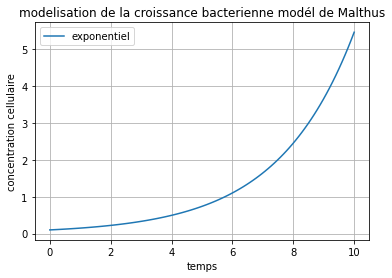

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la simulation
rmax = 0.4 # taux de croissance maximal (h⁻¹)
C0 = 0.1 # Concentration des cellules bactériennes au début de la simulation (10^3 cellules.mL-1)
T = 10 # durée totale de la simulation (heures)
dt = 0.1 # pas de temps (heures)
N_steps = int(T / dt)

# Simulation
time = np.linspace(0, T, N_steps)
C = C0 * np.exp(rmax * time)

# Tracé du graphique
plt.title('modelisation de la croissance bacterienne modél de Malthus') # Titre du graphique
plt.plot(time, C, label='exponentiel') # Nom de la courbe
plt.xlabel('temps') # Axe des X
plt.ylabel('concentration cellulaire') # Axe des Y
plt.grid(True)
plt.legend()
plt.show()



le titre de graphique : modelisation de la croissance bacterienne modél de Malthus
2: courbe exponentiel
3: population double au bout de : 5 heure
4: analyse des resultats: quand rmax = 0.4 : croissance trés rapide. la pente augmente fortement donc population augmente plus vite 
 quand rmax=0.1: dcroissance plus lente. population zugmente progressivement . 
  rmax=0: population constante , aucune croissance .
  rmax=_-0.1 décroissance exponentielle. population diminue progressivement jusqu'a disparition 
 
 5:mites du modele; ressources illimitées , abscence de mortalité, abscence de compétition , environnement constant
  faudrait ajouter  :onsommation des ressources, mortalité, compétition, limitation du glucose, effect environnementaux; pour améliorer le modele il faut ajouter: 

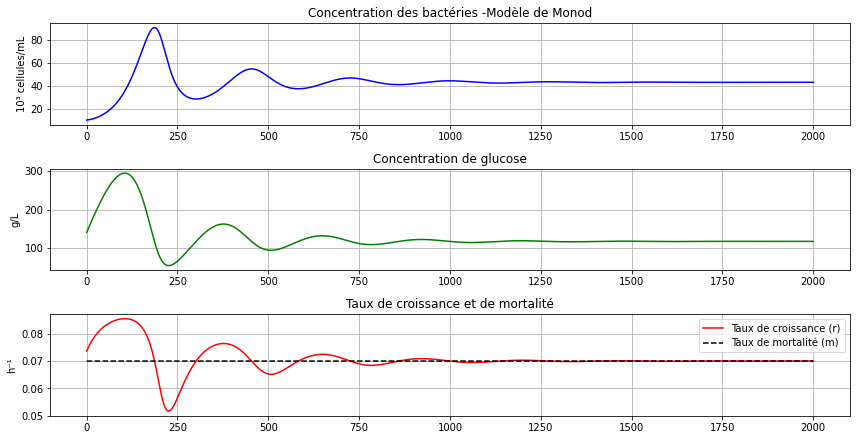

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# PARAMÈTRES DE LA SIMULATION
# ======================
T =  2000 # Durée totale (heures)
dt = 0.1 # Pas de temps (heures)
N_steps = int(T / dt) # Nombre de pas de temps

# ======================
#PARAMÈTRES DE LA SOUCHE
# ======================
rmax = 0.10 # Taux de croissance maximal (h⁻¹)
K = 50 # Affinité pour le substrat (g/L)
m0 = 0.07 # Taux de mortalité minimal (h⁻¹)
C0 = 10 # Concentration initiale de bactéries (10³ cellules/mL)

# ======================
# PARAMÈTRES DU SUBSTRAT (GLUCOSE)
# ======================
initial_glucose = 140 # Concentration initiale de glucose (g/L)
glucose_inflow = 3 # Flux entrant de glucose (g/L/h)

# ====================== 
# INITIALISATION DES TABLEAUX
# ======================
C = np.zeros(N_steps) # Concentration bactérienne
glucose_level = np.zeros(N_steps)
growth_rate = np.zeros(N_steps)
mortality_rate = np.zeros(N_steps)

# ======================
# CONDITIONS INITIALES
# ======================
C[0] = C0
glucose_level[0] = initial_glucose
growth_rate[0] = rmax * glucose_level[0] / (K + glucose_level[0])
mortality_rate[0] = m0

# ======================
# SIMULATION
# ======================
for i in range(1, N_steps):
    # Calcul des taux
    r = rmax * glucose_level[i-1] / (K + glucose_level[i-1])
    
    # Mise à jour de la population bactérienne
    C[i] = C[i-1] + dt * (r -m0) * C[i-1]
    
    # Mise à jour du glucose (consommation + flux entrant)
    
    glucose_level[i] = glucose_level[i-1] -dt * r * C[i-1] + glucose_inflow * dt
    
    
    # Stockage des taux
    growth_rate[i] = r
    mortality_rate[i] = m0
    
# ======================
# AXE DES X EN HEURES
# ======================
time = np.linspace(0, T, N_steps)
    
# ======================
# TRACÉ DES COURBES
# ======================
plt.figure(figsize=(12, 8))
    
# 1. Concentration bactérienne
plt.subplot(4, 1, 1)
plt.plot(time, C, label='Nombre de bactéries', color='blue')
plt.title('Concentration des bactéries -Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.grid(True)
    
# 2. Concentration de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Concentration de glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)
    
#3. Taux de croissance ET mortalité (sur le même graphique)
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate, label='Taux de croissance (r)', color='red')
plt.plot(time, mortality_rate, label='Taux de mortalité (m)', color='black', linestyle='--') # Ligne noire en pointillé
plt.title('Taux de croissance et de mortalité')
plt.ylabel('h⁻¹')
plt.legend() # Affiche la légende pour les deux courbes
plt.grid(True)
    
plt.tight_layout()
plt.show()

In [ ]:
1: décrire les courbes : au début : glucose élevé, croissance forte, bactéries augmentent rapidement  
            puis : glucose diminue progressivement , croissance ralentis 
                 finalement: le glucose devient insuffisanr , r devient inférieur a m , la population seffondre
 elle s'écroule car : le glucose est consommé progressivement.
 quand il devient trop faible: croissance < mortalité donc la population chute 
        
 facteur limitant: concentration en glucose 
    
    2: valeur de r quand la population atteint le maximum :  : maximum atteint donc croissance = mortalité ,
    donc: r=m comme m=0.007h^-1donc la population maximale r=0.07j^-1
                    
    5: effects des paramétres : 
    si rmax augmente : croissance plus rapide , si k augmente : affinité faible les bacteries exploitent moins bien le glucose . 
    si m0 augmente : plus de mortalité : population diminue 
  6: pour maintenir la population : il faut un apport continu de glucose  , sinon les ressources s'epuisent                                 
                
                
                
partie 2: quand T=200 glucose_inflow=3
     décrire les courbes : verte (glucose):diminue progressivement car il est consommé par les bactéries,
                courbe bleu (bactéries): augmente rapidement au début puis diminue puis chute car les ressources deviennent insuffisantes.
              courbe rouge (taux de croissance r): éleVée au début puis avec la baisse du glocose.
                DONC : MOINS IL Y'A DE GLUCOSE : LE TAUX DE CROISSANCE BAISS; LES BACTÉRIES FINISSENT PAR DIMINUER.
                    
fluctuations: quand le glucose augmente: bactérie augmentent donc beaucoup de bactéries: glucose fortement consommé 
quand glucose baisse : population diminue puis le glucose remonte grace au flux entrant, le cycle recommence ensuite équilibre dynamique s'installe. 
    


        

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# Paramètres pour la souche 1
# =============================================
rmax_1 = 0.15 # Taux de croissance maximal (souche 1)
m0_1 = 0.06 # Taux de mortalité de base (souche 1)
K_1 = 800 # Constante de demi-saturation (souche 1)


# =============================================
# Paramètres pour la souche 2
# =============================================
rmax_2 = 0.15 # Taux de croissance maximal (souche 2)
m0_2 = 0.06 # Taux de mortalité de base (souche 2)
K_2 = 650 # Constante de demi-saturation (souche 2) -affinité plus élevée pour le glucose

# =============================================
# Paramètres du glucose
# =============================================
initial_glucose = 1200 # Quantité initiale de glucose
glucose_inflow = 4 # Flux entrant de glucose (0 = système fermé)

# =============================================
# Conditions initiales
#=============================================
C0_1 = 10 # Concentration initiale de la souche 1
C0_2 = 10 # Concentration initiale de la souche 2

# =============================================
# Paramètres de la simulation
# =============================================
t = 0.1 # Pas de temps
T = 2000 # Durée totale de la simulation
N_steps = int(T / dt)# Nombre de pas de temps

# =============================================
# Initialisation des tableaux
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)
  # Stockage des taux
growth_rate_1[i] = r_1
growth_rate_2[i] = r_2
mortality_rate_1[i] = m_1
mortality_rate_2[i] = m_2

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2


# =============================================
# Simulation
# =============================================
for i in range(1, N_steps):
    # Calcul des taux de croissance pour chaque souche (modèle de Monod)
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])
    
    # Mortalité variable (augmente si le glucose est faible)
    #m_1 = m0_1 + 0.01 * (1 -glucose_level[i-1] / initial_glucose)
    #m_2 = m0_2 + 0.01 * (1 -glucose_level[i-1] / initial_glucose)
    
    # Mortalité constante
    m_1 = m0_1 
    m_2 = m0_2
    
    # Mise à jour des populations bactériennes
    C1[i] = C1[i-1] + dt * (r_1 -m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 -m_2) * C2[i-1]
    
   # Consommation totale de glucose (somme des consommations des deux souches)
glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
glucose_level[i] = glucose_level[i-1] -dt * glucose_consumption + glucose_inflow * dt
    

    
# =============================================
# Temps pour l'axe des abscisses
# =============================================
time = np.linspace(0, T, N_steps)
    
# =============================================
# Tracé des courbes
# =============================================
plt.figure(figsize=(12, 12))
    
# Population des bactéries
plt.subplot(4, 1, 1)
lt.plot(time, C1, label='Souche 1', color='blue')
plt.plot(time, C2, label='Souche 2', color='orange')
plt.title('Compétition entre 2 souches -Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)
    
# Niveau de glucoseplt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)
    
# Taux de croissance et mortalité
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
Plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche1)', color='blue', linestyle=':')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance (r) et de mortalité (m)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
    
# Taux de mortalité#
plt.subplot(4, 1, 4)
#plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
#plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
#plt.title('Taux de mortalité (m) au fil du temps')
#plt.xlabel('Temps')
#plt.ylabel('Taux de mortalité (m)')
#plt.legend()
#plt.grid(True)
    
plt.tight_layout()
plt.show()
        

NameError: name 'r_1' is not defined

In [30]:
glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
glucose_level[i] = glucose_level[i-1] -dt * glucose_consumption + glucose_inflow * dt
    

NameError: name 'r_1' is not defined

In [32]:
 
growth_rate_2[i] = r_2
mortality_rate_1[i] = m_1
mortality_rate_2[i] = m_2

NameError: name 'r_1' is not defined

In [33]:
 r_1  = growth_rate_1[i]

NameError: name 'growth_rate_1' is not defined